In [1]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset, WeightedRandomSampler
import numpy as np
import math
import os
import copy
import pandas as pd
from torchvision.io import read_image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [2]:
# Check compute device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
split_rate = 0.8
batch_size = 32
epochs = 100
epochs_1 = 75
epochs_2 = 50
learning_rate = 0.005 # <0.05
learning_rate_1 = learning_rate * 0.1
learning_rate_2 = learning_rate * 0*1 *0.1
top_k_test = 1
weight_decay = 2e-2 #0.0001 - 0.01
momentum = 0
hidden_units = 64
IMG_SIZE = 224

In [4]:

train_data_path = "/kaggle/input/catdog-combined-dataset-hust2024/CatBreeds/CatBreeds/train"
val_data_path = "/kaggle/input/catdog-combined-dataset-hust2024/CatBreeds/CatBreeds/test"
#Transform images
train_data_transforms = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_1 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(90,90)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_2 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(180,180)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_3 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(270,270)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
val_data_transforms = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
#Load data
org_train_dataset = torchvision.datasets.ImageFolder(root=train_data_path, transform=train_data_transforms)
add_train_dataset_1 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_1)
add_train_dataset_2 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_2)
add_train_dataset_3 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_3)
val_dataset = torchvision.datasets.ImageFolder(root=val_data_path, transform=val_data_transforms)

train_dataset = ConcatDataset([org_train_dataset,add_train_dataset_1,add_train_dataset_2,add_train_dataset_3])
class_num = len(org_train_dataset.classes)
#Take small number of data
#dataset = torch.utils.data.Subset(original_dataset,range(int(0.2*len(dataset))))

#Split data at the same ratio for each class
#stratified_split = StratifiedShuffleSplit(n_splits=1, train_size=split_rate, random_state=42)
targets = np.array([label for _, label in train_dataset])
#for train_idx, val_idx in stratified_split.split(np.zeros(len(targets)), targets)
    #train_dataset = Subset(dataset, train_idx)
    #test_dataset = Subset(dataset, val_idx)

#Over sampling

class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in targets])


samples_weight = torch.from_numpy(samples_weight)
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))
#Loader
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers= 4, sampler=sampler)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size = batch_size, shuffle=False, num_workers = 4)
#Print number of samples
print("Number of samples in training set: %d" % (len(train_dataset)))
print("Number of samples in validation set: %d" % (len(val_dataset)))
#Number of class
classes = {}
for i in range(class_num):
    classes[i] = org_train_dataset.classes[i]
print(classes)

Number of samples in training set: 14560
Number of samples in validation set: 910
{0: 'Abyssinian', 1: 'Bengal', 2: 'Birman', 3: 'Bombay', 4: 'Egyptian Mau', 5: 'Exotic Shorthair', 6: 'Norwegian Forest', 7: 'Persian', 8: 'Russian Blue', 9: 'Scottish Fold', 10: 'Siamese', 11: 'Sphynx', 12: 'Turkish Angora'}


In [5]:
def show_transformed_images(Dataset):
    loader = torch.utils.data.DataLoader(Dataset, batch_size = 6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch
    #show images after transform
    grid = torchvision.utils.make_grid(images, nrow = 3)

    plt.figure(figsize=(11, 11))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    print("Labels: ", labels)

Labels:  tensor([ 3,  4,  7, 12, 10,  5])


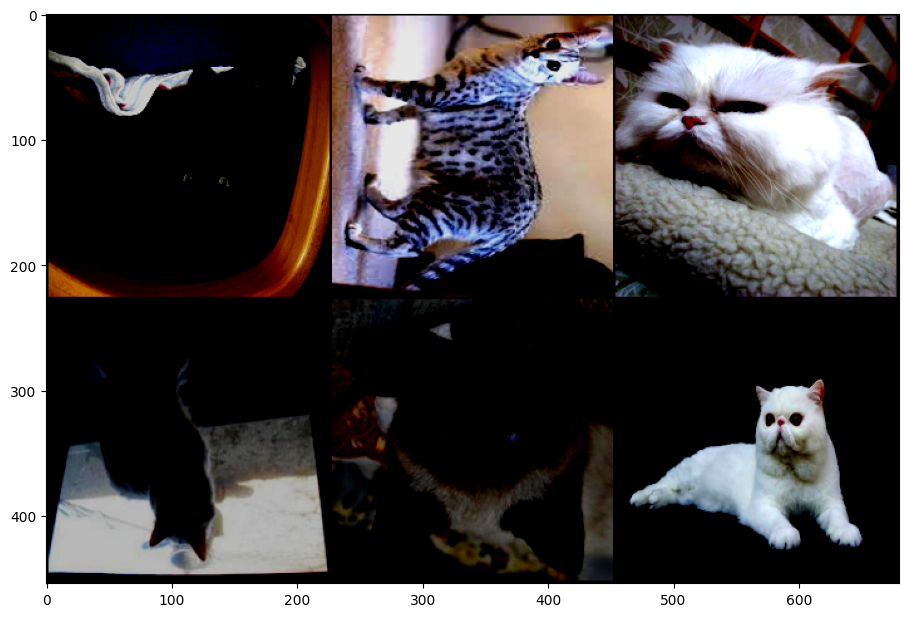

In [6]:
#Show some images
show_transformed_images(train_dataset)

In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        #Block 1
        self.layer1 = nn.Sequential(

            nn.Conv2d(3, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU())
        self.layer2 = nn.Sequential(

            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 2
        self.layer3 = nn.Sequential(

            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU())
        self.layer4 = nn.Sequential(

            nn.Conv2d(hidden_units*2, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 3
        self.layer5 = nn.Sequential(

            nn.Conv2d(hidden_units*2, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU())
        self.layer6 = nn.Sequential(

            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 4
        self.layer7 = nn.Sequential(

            nn.Conv2d(hidden_units*4, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU())
        self.layer8 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 5
        self.layer9 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU())
        self.layer10 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Classifier
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*hidden_units*8, 8192),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(8192, 8192),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(8192, class_num))






    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)

        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)

        return out
model = NeuralNetwork().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = weight_decay, momentum = momentum)

Total number of parameters: 287475789


In [8]:
def evaluate(model, test_dataloader,criterion):
    model.eval()
    corrects_per_epoch = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for data in test_dataloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            total += labels.size(0)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probabilities = torch.softmax(outputs, dim=1)
            _, predict = torch.topk(probabilities, k=top_k_test, dim=1)

            running_loss += loss.item()
            corrects_per_epoch += torch.sum(predict.eq(labels.view(-1, 1))).item()

    epoch_loss = running_loss/len(test_dataloader)
    epoch_acc = 100.00 * corrects_per_epoch / total
    print("Validation acc: %.3f%%, Validation loss: %.3f" % (epoch_acc, epoch_loss))
    return epoch_acc



In [9]:
def train_NN(model, train_dataloader, test_dataloader, criterion, optimizer, number_epochs):
    train_acc_list = []
    test_acc_list = []
    num_epochs = [i for i in range (number_epochs)]
    best_model = None
    for epoch in range(number_epochs):
        print("Epochs number %d" % (epoch + 1))
        model.train()
        running_loss = 0.0
        running_correct = 0.0
        total = 0
        for data in train_dataloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            #Backpropagation
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            #Loss and accuracy
            total += labels.size(0)
            _, predict = torch.max(outputs.data, 1)
            running_loss += loss.item()


            running_correct += (labels == predict).sum().item()
        epoch_loss = running_loss/len(train_dataloader)
        epoch_acc = 100.00 * running_correct / total
        print("Training complete. Got %d out of %d correctly (%.3f%%). Epoch loss: %.3f" % (running_correct, total, epoch_acc, epoch_loss))
        train_acc_list.append(epoch_acc)
        test_acc = evaluate(model, test_dataloader, criterion)
        test_acc_list.append(test_acc)
        print("Best acc:",round(max(test_acc_list),3),'%')
        if test_acc == max(test_acc_list):
            best_model = copy.deepcopy(model)

    torch.save(best_model.state_dict(), "My_model_with_%.3f%%.pth" % (max(test_acc_list)))
    print("Finished")
    plt.plot(num_epochs, np.array(train_acc_list), color = "r", label = "Train accuracy")
    plt.plot(num_epochs, np.array(test_acc_list), color = "b", label = "Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy(%)")
    plt.title("Train accuracy vs Test accuracy")
    plt.legend()
    plt.show()
    #return model
    print("Evaluating best model on the test set...")
    all_labels, all_predictions = get_all_predictions(best_model, test_dataloader)
    print(classification_report(all_labels, all_predictions))
    return best_model,max(test_acc_list)

def get_all_predictions(model, dataloader):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predict = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predict.cpu().numpy())

    return all_labels, all_predictions


Epochs number 1
Training complete. Got 3374 out of 14560 correctly (23.173%). Epoch loss: 2.265
Validation acc: 32.198%, Validation loss: 2.011
Best acc: 32.198 %
Epochs number 2
Training complete. Got 5224 out of 14560 correctly (35.879%). Epoch loss: 1.874
Validation acc: 38.242%, Validation loss: 1.819
Best acc: 38.242 %
Epochs number 3
Training complete. Got 6074 out of 14560 correctly (41.717%). Epoch loss: 1.693
Validation acc: 36.923%, Validation loss: 1.864
Best acc: 38.242 %
Epochs number 4
Training complete. Got 6913 out of 14560 correctly (47.479%). Epoch loss: 1.524
Validation acc: 45.824%, Validation loss: 1.597
Best acc: 45.824 %
Epochs number 5
Training complete. Got 7732 out of 14560 correctly (53.104%). Epoch loss: 1.369
Validation acc: 44.835%, Validation loss: 1.919
Best acc: 45.824 %
Epochs number 6
Training complete. Got 8388 out of 14560 correctly (57.610%). Epoch loss: 1.242
Validation acc: 50.000%, Validation loss: 1.794
Best acc: 50.0 %
Epochs number 7
Training

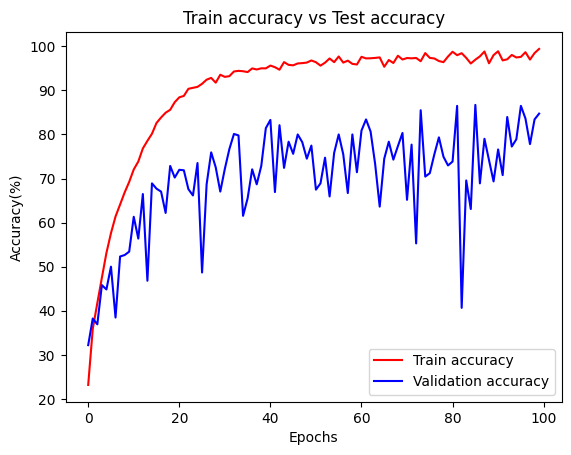

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        70
           1       0.83      0.86      0.85        70
           2       0.81      0.94      0.87        70
           3       0.93      0.97      0.95        70
           4       0.92      0.77      0.84        70
           5       0.78      0.89      0.83        70
           6       0.90      0.93      0.92        70
           7       0.93      0.79      0.85        70
           8       0.84      0.99      0.91        70
           9       0.98      0.73      0.84        70
          10       0.95      0.81      0.88        70
          11       0.89      0.97      0.93        70
          12       0.81      0.84      0.83        70

    accuracy                           0.87       910
   macro avg       0.87      0.87      0.87       910
weighted avg       0.87      0.87      0.87       910



In [10]:
best_model,best_acc = train_NN(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epochs number 1
Training complete. Got 14518 out of 14560 correctly (99.712%). Epoch loss: 0.035
Validation acc: 89.121%, Validation loss: 0.423
Best acc: 89.121 %
Epochs number 2
Training complete. Got 14541 out of 14560 correctly (99.870%). Epoch loss: 0.026
Validation acc: 90.110%, Validation loss: 0.405
Best acc: 90.11 %
Epochs number 3
Training complete. Got 14552 out of 14560 correctly (99.945%). Epoch loss: 0.023
Validation acc: 89.341%, Validation loss: 0.402
Best acc: 90.11 %
Epochs number 4
Training complete. Got 14556 out of 14560 correctly (99.973%). Epoch loss: 0.021
Validation acc: 89.341%, Validation loss: 0.402
Best acc: 90.11 %
Epochs number 5
Training complete. Got 14558 out of 14560 correctly (99.986%). Epoch loss: 0.020
Validation acc: 88.791%, Validation loss: 0.405
Best acc: 90.11 %
Epochs number 6
Training complete. Got 14559 out of 14560 correctly (99.993%). Epoch loss: 0.019
Validation acc: 89.780%, Validation loss: 0.395
Best acc: 90.11 %
Epochs number 7
Train

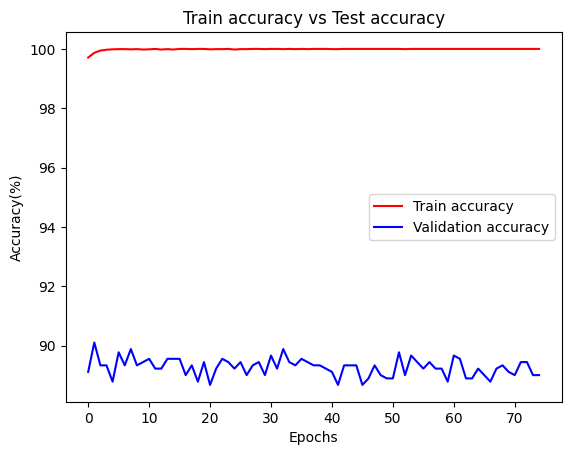

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        70
           1       0.90      0.89      0.89        70
           2       0.86      0.91      0.89        70
           3       0.90      1.00      0.95        70
           4       0.89      0.83      0.86        70
           5       0.85      0.90      0.88        70
           6       0.92      0.97      0.94        70
           7       0.92      0.83      0.87        70
           8       0.92      0.96      0.94        70
           9       0.97      0.83      0.89        70
          10       0.94      0.87      0.90        70
          11       0.99      0.99      0.99        70
          12       0.85      0.87      0.86        70

    accuracy                           0.90       910
   macro avg       0.90      0.90      0.90       910
weighted avg       0.90      0.90      0.90       910



In [11]:
best_model_copy = copy.deepcopy(best_model)
optimizer_1 = torch.optim.SGD(best_model_copy.parameters(), lr=learning_rate_1, weight_decay = weight_decay, momentum = momentum)
best_model_1,best_acc_1 = train_NN(best_model_copy, train_dataloader, val_dataloader, loss_fn, optimizer_1, epochs_1)

Epochs number 1
Training complete. Got 14550 out of 14560 correctly (99.931%). Epoch loss: 0.024
Validation acc: 89.890%, Validation loss: 0.401
Best acc: 89.89 %
Epochs number 2
Training complete. Got 14549 out of 14560 correctly (99.924%). Epoch loss: 0.023
Validation acc: 90.000%, Validation loss: 0.399
Best acc: 90.0 %
Epochs number 3
Training complete. Got 14554 out of 14560 correctly (99.959%). Epoch loss: 0.024
Validation acc: 90.110%, Validation loss: 0.399
Best acc: 90.11 %
Epochs number 4
Training complete. Got 14543 out of 14560 correctly (99.883%). Epoch loss: 0.023
Validation acc: 89.670%, Validation loss: 0.403
Best acc: 90.11 %
Epochs number 5
Training complete. Got 14547 out of 14560 correctly (99.911%). Epoch loss: 0.024
Validation acc: 90.000%, Validation loss: 0.397
Best acc: 90.11 %
Epochs number 6
Training complete. Got 14548 out of 14560 correctly (99.918%). Epoch loss: 0.024
Validation acc: 90.000%, Validation loss: 0.401
Best acc: 90.11 %
Epochs number 7
Trainin

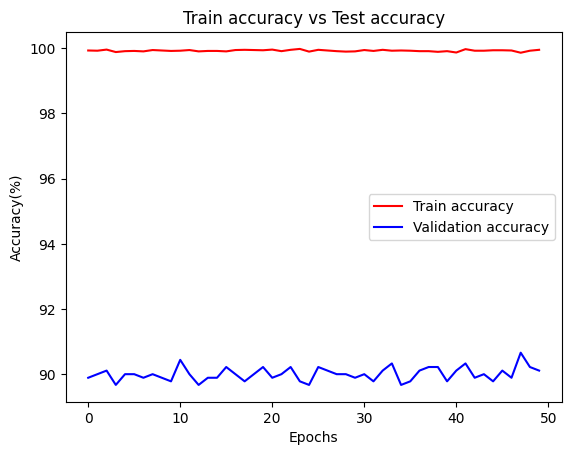

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        70
           1       0.91      0.87      0.89        70
           2       0.88      0.93      0.90        70
           3       0.93      1.00      0.97        70
           4       0.88      0.86      0.87        70
           5       0.86      0.90      0.88        70
           6       0.93      0.97      0.95        70
           7       0.91      0.86      0.88        70
           8       0.93      0.97      0.95        70
           9       0.97      0.86      0.91        70
          10       0.95      0.87      0.91        70
          11       0.97      0.99      0.98        70
          12       0.84      0.87      0.85        70

    accuracy                           0.91       910
   macro avg       0.91      0.91      0.91       910
weighted avg       0.91      0.91      0.91       910



In [12]:
if best_acc_1 > best_acc:
    best_model_1_copy = copy.deepcopy(best_model_1)
else:
    best_model_1_copy = copy.deepcopy(best_model)
optimizer_2 = torch.optim.SGD(best_model_1_copy.parameters(), lr=learning_rate_2, weight_decay = weight_decay, momentum = momentum)
best_model_2,best_acc_2 = train_NN(best_model_1_copy, train_dataloader, val_dataloader, loss_fn, optimizer_2, epochs_2)

In [13]:
print(f"Best Accuracy after first training: {best_acc:.3f}%")
print(f"Best Accuracy after second training: {best_acc_1:.3f}%")
print(f"Best Accuracy after final training: {best_acc_2:.3f}%")

Best Accuracy after first training: 86.703%
Best Accuracy after second training: 90.110%
Best Accuracy after final training: 90.659%
